# Retail Store Data Analysis and Transformation

This document represents a data pipeline of following steps: 
- ingestion of retail_store_us file (orders, returns and users data), 
- exploratory data analysis,
- data cleaning and transformation,
- creating reporting data for visualization in Power BI.

In [2]:
# check if all libraries are installed

import pandas as pd
import numpy as np
import openpyxl
import matplotlib
import matplotlib.pyplot as plt 
import seaborn as sns

from pathlib import Path

ModuleNotFoundError: No module named 'pandas'

In [2]:
# adjust display settings

pd.set_option('display.max_columns', 50)

### Load Raw Data

In [1]:
# ingestion of data

excel_file = 'retail_store_us.xlsx'

orders_df = pd.read_excel(excel_file, sheet_name='Orders')
returns_df = pd.read_excel(excel_file, sheet_name='Returns')
users_df = pd.read_excel(excel_file, sheet_name='Users')

NameError: name 'pd' is not defined

### Basic Exploration

In [4]:
# basic info about dataframes

orders_df.info()
returns_df.info()
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Row ID                1952 non-null   int64         
 1   Order Priority        1952 non-null   object        
 2   Discount              1952 non-null   float64       
 3   Unit Price            1952 non-null   float64       
 4   Shipping Cost         1952 non-null   float64       
 5   Customer ID           1952 non-null   int64         
 6   Customer Name         1952 non-null   object        
 7   Ship Mode             1952 non-null   object        
 8   Customer Segment      1952 non-null   object        
 9   Product Category      1952 non-null   object        
 10  Product Sub-Category  1952 non-null   object        
 11  Product Container     1952 non-null   object        
 12  Product Name          1952 non-null   object        
 13  Product Base Margi

### Column Names Normalization

In [5]:
# clean and normalize column names for enabling further steps

def clean_cols(df):
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('-', '_')
    )
    return df

orders_df = clean_cols(orders_df)
returns_df = clean_cols(returns_df)
users_df = clean_cols(users_df)

In [6]:
# check transformed column names

print('orders_df columns:', orders_df.columns.tolist())
print('returns_df columns:', returns_df.columns.tolist())
print('users_df columns:', users_df.columns.tolist())

orders_df columns: ['row_id', 'order_priority', 'discount', 'unit_price', 'shipping_cost', 'customer_id', 'customer_name', 'ship_mode', 'customer_segment', 'product_category', 'product_sub_category', 'product_container', 'product_name', 'product_base_margin', 'country', 'region', 'state_or_province', 'city', 'postal_code', 'order_date', 'ship_date', 'profit', 'quantity_ordered_new', 'sales', 'order_id']
returns_df columns: ['order_id', 'status']
users_df columns: ['region', 'manager']


In [7]:
# quick data overview - after column names transformation

print(orders_df.head())
print(orders_df.info())
print(orders_df.describe())

   row_id order_priority  discount  unit_price  shipping_cost  customer_id  \
0   20847           High      0.01        2.84           0.93            3   
1   20228  Not Specified      0.02      500.98          26.00            5   
2   21776       Critical      0.06        9.48           7.29           11   
3   24844         Medium      0.09       78.69          19.99           14   
4   24846         Medium      0.08        3.28           2.31           14   

       customer_name       ship_mode customer_segment product_category  \
0      Bonnie Potter     Express Air        Corporate  Office Supplies   
1     Ronnie Proctor  Delivery Truck      Home Office        Furniture   
2      Marcus Dunlap     Regular Air      Home Office        Furniture   
3  Gwendolyn F Tyson     Regular Air   Small Business        Furniture   
4  Gwendolyn F Tyson     Regular Air   Small Business  Office Supplies   

  product_sub_category product_container  \
0  Pens & Art Supplies          Wrap Bag  

Notes: 
- all numeric columns are float64 format -> ok. 
- all date type columns are datetime format -> ok.
- all id columns are int format -> ok.

In [8]:
orders_df.shape

(1952, 25)

### Outliers Detection

<Axes: xlabel='sales'>

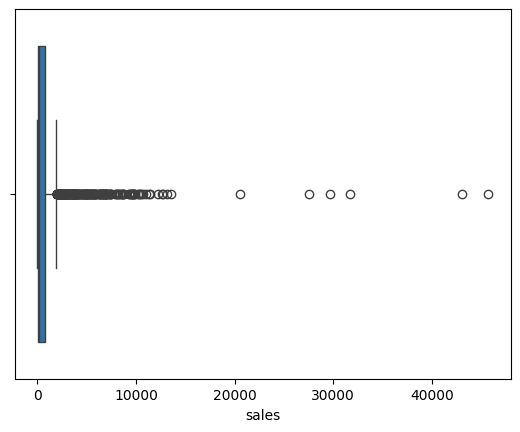

In [9]:
# detect sales outliers

sns.boxplot(data=orders_df, x='sales')

In [10]:
# check 99th percentile value to exclude sales outliers

print('99th percentile: {0}'.format(orders_df.sales.quantile(.99))) # 99th percentile

99th percentile: 9830.0383


In [11]:
quantiles = orders_df['sales'].quantile([0.25, 0.5, 0.75, 0.99])
print(quantiles)

0.25      58.8075
0.50     202.3950
0.75     802.9450
0.99    9830.0383
Name: sales, dtype: float64


In [12]:
lower_limit = orders_df['sales'].quantile(0.01)  # 1st percentile
upper_limit = orders_df['sales'].quantile(0.99)  # 99th percentile

print(f'Lower threshold: {lower_limit}, Upper threshold: {upper_limit}')

Lower threshold: 6.206000000000001, Upper threshold: 9830.0383


In [13]:
orders_df = orders_df[(orders_df['sales'] >= lower_limit) & (orders_df['sales'] <= upper_limit)]

In [14]:
orders_df.loc[orders_df.sales>10000]

,row_id,order_priority,discount,unit_price,shipping_cost,customer_id,customer_name,ship_mode,customer_segment,product_category,product_sub_category,product_container,product_name,product_base_margin,country,region,state_or_province,city,postal_code,order_date,ship_date,profit,quantity_ordered_new,sales,order_id


### Missing Data

In [15]:
# check for missing values

print(orders_df.isnull().sum())
print(returns_df.isnull().sum())
print(users_df.isnull().sum())

row_id                   0
order_priority           0
discount                 0
unit_price               0
shipping_cost            0
customer_id              0
customer_name            0
ship_mode                0
customer_segment         0
product_category         0
product_sub_category     0
product_container        0
product_name             0
product_base_margin     16
country                  0
region                   0
state_or_province        0
city                     0
postal_code              0
order_date               0
ship_date                0
profit                   0
quantity_ordered_new     0
sales                    0
order_id                 0
dtype: int64
order_id    0
status      0
dtype: int64
region     0
manager    0
dtype: int64


In [16]:
# missing data of product_base_margin column

orders_df[orders_df['product_base_margin'].isna()]

,row_id,order_priority,discount,unit_price,shipping_cost,customer_id,customer_name,ship_mode,customer_segment,product_category,product_sub_category,product_container,product_name,product_base_margin,country,region,state_or_province,city,postal_code,order_date,ship_date,profit,quantity_ordered_new,sales,order_id
181,18261,Critical,0.06,276.20,24.49,335,Curtis O'Connell,Regular Air,Corporate,Furniture,Chairs & Chairmats,Large Box,SAFCO Arco Folding Chair,NaN,United States,West,Oregon,Medford,97504,2015-05-04,2015-05-05,2639.4708,14,3825.32,87277
271,18305,Critical,0.01,128.24,12.65,508,Cameron Owens,Regular Air,Corporate,Furniture,Chairs & Chairmats,Medium Box,SAFCO Folding Chair Trolley,NaN,United States,South,Kentucky,Covington,41011,2015-04-18,2015-04-21,140.1354,4,554.08,87357
483,24764,Critical,0.09,349.45,60.00,868,Sharon Ellis,Delivery Truck,Corporate,Furniture,Tables,Jumbo Drum,SAFCO PlanMaster Heigh-Adjustable Drafting Tab...,NaN,United States,Central,Minnesota,Shoreview,55126,2015-03-06,2015-03-07,-2946.0510,12,3918.98,91195
660,19185,High,0.09,349.45,60.00,1178,Sandy Hunt,Delivery Truck,Consumer,Furniture,Tables,Jumbo Drum,SAFCO PlanMaster Heigh-Adjustable Drafting Tab...,NaN,United States,South,Florida,Altamonte Springs,32701,2015-04-09,2015-04-10,-369.1100,7,2307.26,89787
700,20592,Medium,0.03,128.24,12.65,1237,Eva Simpson,Regular Air,Corporate,Furniture,Chairs & Chairmats,Medium Box,SAFCO Folding Chair Trolley,NaN,United States,Central,Texas,Carrollton,75007,2015-01-31,2015-02-02,790.4640,9,1145.60,86075
727,21848,Not Specified,0.08,128.24,12.65,1267,Rosemary Branch,Regular Air,Corporate,Furniture,Chairs & Chairmats,Medium Box,SAFCO Folding Chair Trolley,NaN,United States,South,Florida,Boca Raton,33433,2015-05-12,2015-05-13,-379.3440,3,366.44,89515
734,22125,Low,0.10,238.40,24.49,1281,Pauline Denton,Regular Air,Small Business,Furniture,Chairs & Chairmats,Large Box,Safco Contoured Stacking Chairs,NaN,United States,Central,Indiana,Vincennes,47591,2015-01-24,2015-01-26,875.2844,8,1774.50,89112
736,4125,Low,0.10,238.40,24.49,1282,Dana Sharpe,Regular Air,Small Business,Furniture,Chairs & Chairmats,Large Box,Safco Contoured Stacking Chairs,NaN,United States,East,Pennsylvania,Philadelphia,19134,2015-01-24,2015-01-26,460.6760,30,6654.39,29319
977,22593,High,0.09,349.45,60.00,1739,Edna Pierce,Delivery Truck,Corporate,Furniture,Tables,Jumbo Drum,SAFCO PlanMaster Heigh-Adjustable Drafting Tab...,NaN,United States,South,North Carolina,Goldsboro,27534,2015-05-03,2015-05-04,-90.7480,17,5835.41,85867
1228,19914,Not Specified,0.08,95.99,35.00,2211,Anita Hahn,Express Air,Home Office,Office Supplies,Storage & Organization,Large Box,Safco Industrial Wire Shelving,NaN,United States,East,Maryland,Bowie,20715,2015-01-01,2015-01-03,-425.2084,2,193.88,88028


profit margin = profit / sales - 1 -> this is not the consistent logic in the data.

In [17]:
# overall mean of of product_base_margin per product_category

orders_df.groupby('product_category')['product_base_margin'].apply(lambda x: x.mean())

product_category
Furniture          0.595538
Office Supplies    0.463672
Technology         0.565021
Name: product_base_margin, dtype: float64

In [18]:
# overall missing data rate of product_base_margin per product_category

orders_df.groupby('product_category')['product_base_margin'].apply(lambda x: x.isna().mean())

product_category
Furniture          0.032995
Office Supplies    0.002868
Technology         0.000000
Name: product_base_margin, dtype: float64

In [19]:
# overall missing data % of product_base_margin in total data

orders_df['product_base_margin'].isna().value_counts(normalize=True)

product_base_margin
False    0.991632
True     0.008368
Name: proportion, dtype: float64

Notes: 
- due to unknown calculation, missing data will be dropped from dataset.
- total % of missing data is only 0.8% -> not significant. 

In [20]:
# drop all rows with missing data 

orders_df = orders_df.dropna()

In [21]:
# quick overall data check

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896 entries, 0 to 1951
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   row_id                1896 non-null   int64         
 1   order_priority        1896 non-null   object        
 2   discount              1896 non-null   float64       
 3   unit_price            1896 non-null   float64       
 4   shipping_cost         1896 non-null   float64       
 5   customer_id           1896 non-null   int64         
 6   customer_name         1896 non-null   object        
 7   ship_mode             1896 non-null   object        
 8   customer_segment      1896 non-null   object        
 9   product_category      1896 non-null   object        
 10  product_sub_category  1896 non-null   object        
 11  product_container     1896 non-null   object        
 12  product_name          1896 non-null   object        
 13  product_base_margin   1

### Duplicated Data

In [22]:
# check duplicates of row_id columns

print(orders_df['row_id'].value_counts())

row_id
22015    2
22597    1
23654    1
23181    1
20366    1
        ..
18320    1
18321    1
18322    1
22378    1
24847    1
Name: count, Length: 1895, dtype: int64


In [23]:
# check row_id=22015 that has duplicate id

orders_df[orders_df['row_id'].isin([22015])]

,row_id,order_priority,discount,unit_price,shipping_cost,customer_id,customer_name,ship_mode,customer_segment,product_category,product_sub_category,product_container,product_name,product_base_margin,country,region,state_or_province,city,postal_code,order_date,ship_date,profit,quantity_ordered_new,sales,order_id
328,22015,Critical,0.09,154.13,69.0,605,Alison Peters Wooten,Express Air,Corporate,Furniture,Tables,Large Box,Laminate Occasional Tables,0.68,United States,East,New York,West Islip,11795,2015-03-14,2015-03-15,-1763.7477,10,1494.63,91144
1812,22015,Critical,0.05,159.99,5.5,3155,Julian Keith Mayer,Regular Air,Consumer,Technology,Computer Peripherals,Small Box,Gyration RF Keyboard,0.49,United States,South,Florida,Sanford,32771,2015-04-19,2015-04-21,12.2640,23,3600.65,86902


In [24]:
# check duplicates or uniquenss of rows per ids available in the dataset: row_id, customer_id and order_id

print('Duplicates:', orders_df.duplicated(subset=['row_id', 'customer_id', 'order_id']).sum())

Duplicates: 0


### Connecting Datasets

In [25]:
# merge orders_df and users_df via region column to get manager name to the main order_users_df table

orders_users_df = pd.merge(orders_df, users_df, on='region', how='left')

In [26]:
orders_users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   row_id                1896 non-null   int64         
 1   order_priority        1896 non-null   object        
 2   discount              1896 non-null   float64       
 3   unit_price            1896 non-null   float64       
 4   shipping_cost         1896 non-null   float64       
 5   customer_id           1896 non-null   int64         
 6   customer_name         1896 non-null   object        
 7   ship_mode             1896 non-null   object        
 8   customer_segment      1896 non-null   object        
 9   product_category      1896 non-null   object        
 10  product_sub_category  1896 non-null   object        
 11  product_container     1896 non-null   object        
 12  product_name          1896 non-null   object        
 13  product_base_margi

### Feature Encoding

In [27]:
# create is_returned feature to distinguish order status

orders_users_df['is_returned'] = orders_users_df['order_id'].isin(returns_df['order_id']).astype(int)

In [28]:
orders_users_df['is_returned'].value_counts()

is_returned
0    1882
1      14
Name: count, dtype: int64

In [29]:
orders_users_df['is_returned'].value_counts(normalize=True)

is_returned
0    0.992616
1    0.007384
Name: proportion, dtype: float64

Only 15 times happened that orders were returned, or in total 0.7% of orders were returned. 
That is a high rate of success of order completion.

In [30]:
orders_users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   row_id                1896 non-null   int64         
 1   order_priority        1896 non-null   object        
 2   discount              1896 non-null   float64       
 3   unit_price            1896 non-null   float64       
 4   shipping_cost         1896 non-null   float64       
 5   customer_id           1896 non-null   int64         
 6   customer_name         1896 non-null   object        
 7   ship_mode             1896 non-null   object        
 8   customer_segment      1896 non-null   object        
 9   product_category      1896 non-null   object        
 10  product_sub_category  1896 non-null   object        
 11  product_container     1896 non-null   object        
 12  product_name          1896 non-null   object        
 13  product_base_margi

In [31]:
# create order_month feature

orders_users_df['order_month'] = orders_users_df['order_date'].dt.month                # useful for ordering
orders_users_df['order_month_name'] = orders_users_df['order_date'].dt.month_name()    # useful for visualisation

In [32]:
# create order_year feature

orders_users_df['order_year'] = orders_users_df['order_date'].dt.year

In [33]:
orders_users_df.head()

,row_id,order_priority,discount,unit_price,shipping_cost,customer_id,customer_name,ship_mode,customer_segment,product_category,product_sub_category,product_container,product_name,product_base_margin,country,region,state_or_province,city,postal_code,order_date,ship_date,profit,quantity_ordered_new,sales,order_id,manager,is_returned,order_month,order_month_name,order_year
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,Pens & Art Supplies,Wrap Bag,SANFORD Liquid Accent™ Tank-Style Highlighters,0.54,United States,West,Washington,Anacortes,98221,2015-01-07,2015-01-08,4.5600,4,13.01,88522,William,0,1,January,2015
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,Chairs & Chairmats,Jumbo Drum,Global Troy™ Executive Leather Low-Back Tilter,0.60,United States,West,California,San Gabriel,91776,2015-06-13,2015-06-15,4390.3665,12,6362.85,90193,William,0,6,June,2015
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,Office Furnishings,Small Pack,"DAX Two-Tone Rosewood/Black Document Frame, De...",0.45,United States,East,New Jersey,Roselle,7203,2015-02-15,2015-02-17,-53.8096,22,211.15,90192,Erin,0,2,February,2015
3,24844,Medium,0.09,78.69,19.99,14,Gwendolyn F Tyson,Regular Air,Small Business,Furniture,Office Furnishings,Small Box,Howard Miller 12-3/4 Diameter Accuwave DS ™ Wa...,0.43,United States,Central,Minnesota,Prior Lake,55372,2015-05-12,2015-05-14,803.4705,16,1164.45,86838,Chris,0,5,May,2015
4,24846,Medium,0.08,3.28,2.31,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,Pens & Art Supplies,Wrap Bag,Newell 321,0.56,United States,Central,Minnesota,Prior Lake,55372,2015-05-12,2015-05-13,-24.0300,7,22.23,86838,Chris,0,5,May,2015


In [34]:
# calculate net_sales = exclude sales when orders were returned

orders_users_df['net_sales'] = orders_users_df['sales'] * (1 - orders_users_df['is_returned'])

In [35]:
orders_users_df.tail()

,row_id,order_priority,discount,unit_price,shipping_cost,customer_id,customer_name,ship_mode,customer_segment,product_category,product_sub_category,product_container,product_name,product_base_margin,country,region,state_or_province,city,postal_code,order_date,ship_date,profit,quantity_ordered_new,sales,order_id,manager,is_returned,order_month,order_month_name,order_year,net_sales
1891,19842,High,0.01,10.90,7.46,3397,Andrea Shaw,Regular Air,Small Business,Office Supplies,Storage & Organization,Small Box,Crate-A-Files™,0.59,United States,Central,Illinois,Danville,61832,2015-03-11,2015-03-12,-116.7600,18,207.31,87536,Chris,0,3,March,2015,207.31
1892,19843,High,0.10,7.99,5.03,3397,Andrea Shaw,Regular Air,Small Business,Technology,Telephones and Communication,Medium Box,Bell Sonecor JB700 Caller ID,0.60,United States,Central,Illinois,Danville,61832,2015-03-11,2015-03-12,-160.9520,22,143.12,87536,Chris,0,3,March,2015,143.12
1893,26208,Not Specified,0.08,11.97,5.81,3399,Marvin Reid,Regular Air,Small Business,Office Supplies,Pens & Art Supplies,Small Pack,Staples SlimLine Pencil Sharpener,0.60,United States,Central,Illinois,Des Plaines,60016,2015-03-29,2015-03-31,-41.8700,5,59.98,87534,Chris,0,3,March,2015,59.98
1894,24911,Medium,0.10,9.38,4.93,3400,Florence Gold,Express Air,Small Business,Furniture,Office Furnishings,Small Box,Eldon Expressions Punched Metal & Wood Desk Ac...,0.57,United States,East,West Virginia,Fairmont,26554,2015-04-04,2015-04-04,-24.7104,15,135.78,87537,Erin,0,4,April,2015,135.78
1895,25914,High,0.10,105.98,13.99,3403,Tammy Buckley,Express Air,Consumer,Furniture,Office Furnishings,Medium Box,"Tenex 46"" x 60"" Computer Anti-Static Chairmat,...",0.65,United States,West,Wyoming,Cheyenne,82001,2015-02-08,2015-02-11,349.4850,5,506.50,87530,William,0,2,February,2015,506.50


In [36]:
# calculate shipment_days to explore delivery performance

orders_users_df['ship_days'] = (orders_users_df['ship_date'] - orders_users_df['order_date']).dt.days

In [37]:
# check shipment_days distribution, possible negative values or data issues

orders_users_df['ship_days'].describe()

count    1896.000000
mean        1.945148
std         1.712640
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max        10.000000
Name: ship_days, dtype: float64

In [38]:
# ship_mode distribution in %

orders_users_df['ship_mode'].value_counts(normalize=True)

ship_mode
Regular Air       0.736287
Delivery Truck    0.139241
Express Air       0.124473
Name: proportion, dtype: float64

Max shipping delay period is 10 days, whereas overall, the majority of delivery, over 75% are delivered within 2 days. 

Over 85% of total delivery is done via air transportation, among two main types: air and truck.

Since relatively small portion of deliveries are with significant delays (over 2 days), no further binning of data is needed.

### Visual Data Exploration

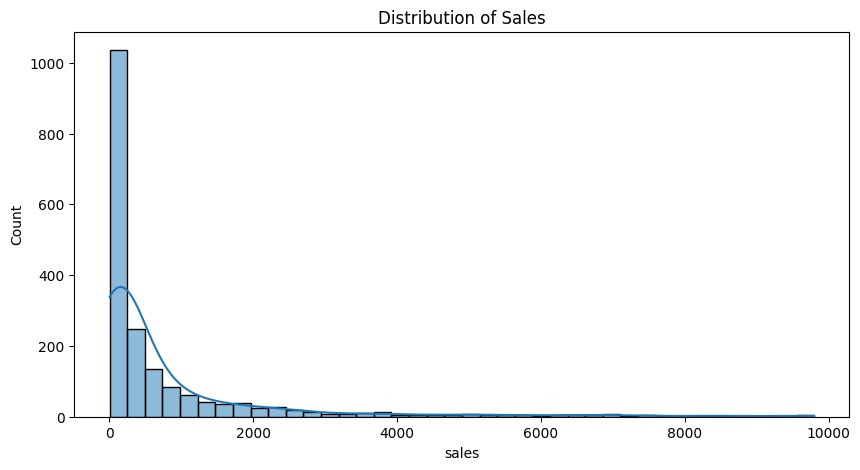

In [39]:
# sales distribution

plt.figure(figsize=(10,5))
sns.histplot(orders_users_df['sales'], bins=40, kde=True)
plt.title('Distribution of Sales')
plt.show()

Approximately 75% of orders are generating around 2k in sales in average.

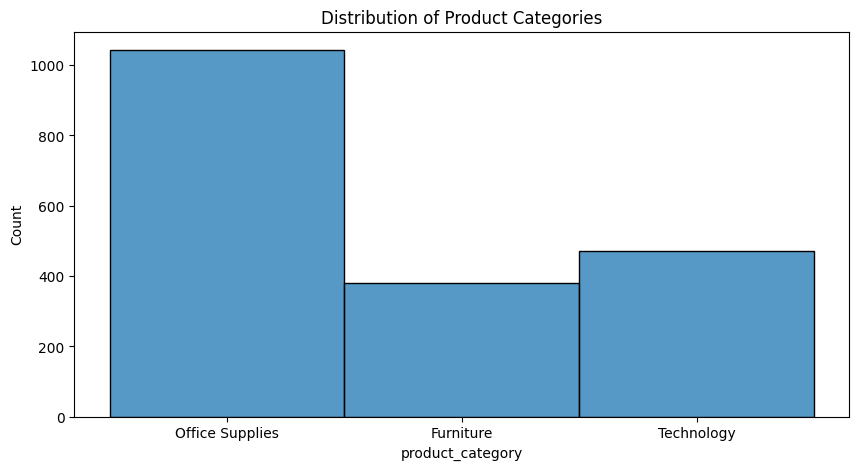

In [40]:
# product categories distribution

plt.figure(figsize=(10,5))
sns.histplot(orders_users_df['product_category'], bins=40)
plt.title('Distribution of Product Categories')
plt.show()

Number of orders of office supplies category compounds to the sum of rest of the categories: furniture and technology.

<Axes: xlabel='region'>

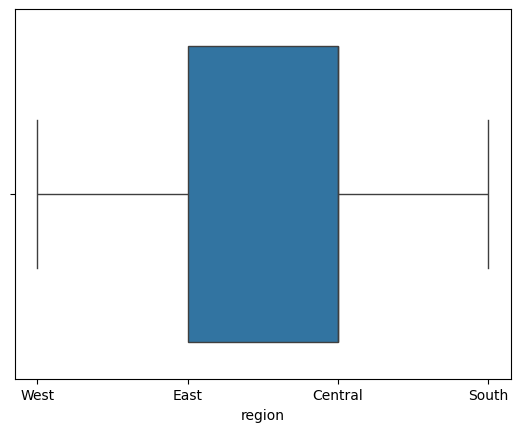

In [41]:
# region order distribution

sns.boxplot(data=orders_users_df, x='region')

Orders are made almost eaqually across 4 regions in US.

<Axes: xlabel='region', ylabel='Count'>

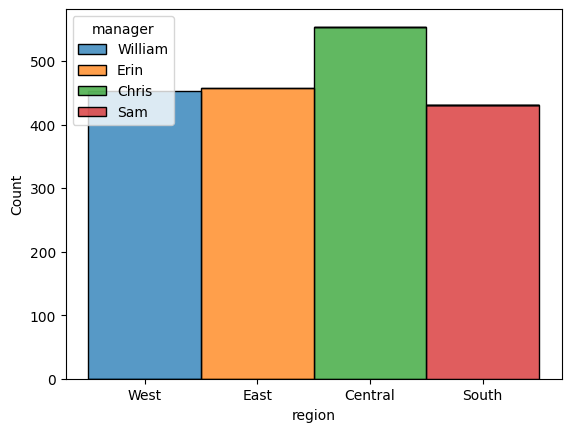

In [42]:
# manager per region distribution

sns.histplot(data=orders_users_df, x='region', hue='manager', multiple='stack')

Central region has the most number of orders and it's managed by Chris.

<Axes: title={'center': 'Monthly Sales'}, xlabel='order_month'>

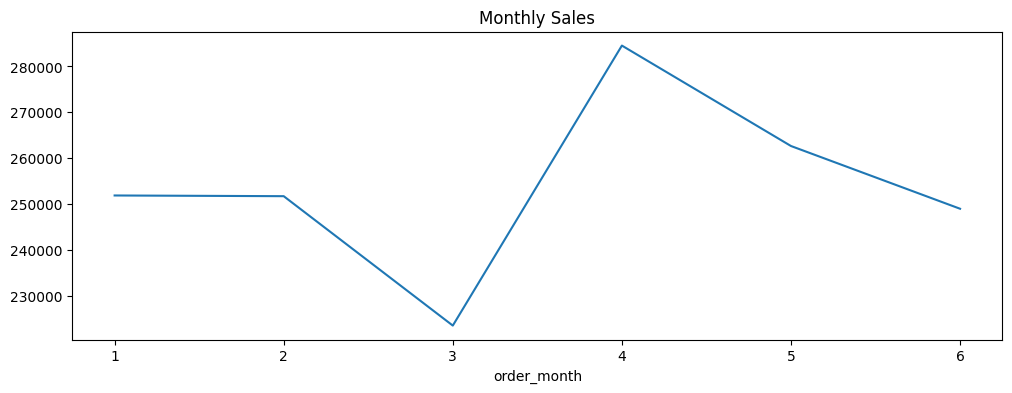

In [43]:
# sales monthly trends

orders_by_month = orders_users_df.groupby('order_month')['sales'].sum()
orders_by_month.plot(figsize=(12, 4), title='Monthly Sales')

Peak of sales happens in April, and overall trend is high during the spring season. The lowest monthly sales happened in the end of Q1 or in March.

In [44]:
# reporting summary table with aggregated metrics

report_df = (
    orders_users_df.groupby(['order_month', 'region', 'product_category'], as_index=False)
    .agg(
        total_sales=('sales', 'sum'),
        total_net_sales=('net_sales', 'sum'),
        total_quantity=('quantity_ordered_new', 'sum'),
        total_orders=('order_id', 'nunique'),
        total_customers=('customer_id', 'nunique'),
        total_profit=('profit', 'sum'),
        returns_count=('is_returned', 'sum')
    )
)

report_df['avg_order_value'] = report_df['total_sales'] / report_df['total_orders']
report_df['return_rate'] = report_df['returns_count'] / report_df['total_orders']
report_df['profit_margin_%'] = (report_df['total_profit'] / report_df['total_sales']) * 100

report_df.head()


,order_month,region,product_category,total_sales,total_net_sales,total_quantity,total_orders,total_customers,total_profit,returns_count,avg_order_value,return_rate,profit_margin_%
0,1,Central,Furniture,24220.58,24220.58,177,20,20,-7498.073000,0,1211.029000,0.0,-30.957446
1,1,Central,Office Supplies,10301.46,10301.46,498,43,47,1678.081460,0,239.568837,0.0,16.289744
2,1,Central,Technology,25177.61,25177.61,219,24,23,5431.678872,0,1049.067083,0.0,21.573449
3,1,East,Furniture,22989.89,22989.89,213,21,22,-6211.991098,0,1094.756667,0.0,-27.020534
4,1,East,Office Supplies,13013.27,13013.27,503,42,42,1388.618500,0,309.839762,0.0,10.670788


In [45]:
# save the reporting tables for Power BI visualisation steps

output_dir = Path('.')
orders_users_df.to_csv(output_dir / "reporting_table.csv", index=False)
report_df.to_csv(output_dir / "reporting_aggregated.csv", index=False)